# 1. Can you remove a protected attribute?

**Claim under test:** deleting the protected attribute, and then deleting the
features you think are proxies for it, makes a model blind to that attribute.

This is *fairness through unawareness*. It is what "Filter 2: Proxy Variable
Removal" does when it strips postcode, neighbourhood, school and phone carrier.

**It does not work, and the failure is measurable.** The test is an adversary:
train a model to predict the protected attribute from the features that remain.
If it beats chance by a meaningful margin, the information is still there and so
is the discrimination channel.

- Dwork et al., *Fairness Through Awareness* (2012) - named the fallacy
- Corbett-Davies & Goel, *The Measure and Mismeasure of Fairness*
  (`papers/corbett-davies-2018-measure-and-mismeasure.pdf`) - the modern critique
- Elazar & Goldberg (2018), Gonen & Goldberg, *Lipstick on a Pig* (2019) -
  removing the surface marker leaves the information intact

**AI Act:** Article 10(2)(f) asks for examination of possible biases. An
unmeasured removal step does not satisfy it.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

RNG = np.random.default_rng(7)
N = 8000

## A lending file where the protected attribute shapes the record

The point of the simulation is that gender is not one column. It is spread
across the whole record: career gaps, part-time history, occupational
segregation, where people live. That is what real data looks like, and it is why
deleting a column changes little.

In [2]:
gender = RNG.choice(['Woman', 'Man'], N, p=[0.42, 0.58])
is_woman = gender == 'Woman'

career_gap = RNG.gamma(2.2, 1.1, N) * np.where(is_woman, 1.9, 1.0)
part_time  = RNG.binomial(1, np.where(is_woman, 0.34, 0.09), N)
occupation = np.where(
    RNG.random(N) < np.where(is_woman, 0.55, 0.22),
    RNG.choice(['Nursing', 'Teaching', 'Admin'], N),
    RNG.choice(['Engineering', 'Trades', 'Finance'], N))
postcode_income_z = RNG.normal(np.where(is_woman, -0.18, 0.05), 1.0, N)
school   = RNG.choice(['S_A', 'S_B', 'S_C', 'S_D'], N, p=[0.30, 0.30, 0.25, 0.15])
tenure   = RNG.gamma(3, 1.4, N) * np.where(is_woman, 0.85, 1.0)
income   = np.exp(RNG.normal(np.where(is_woman, 10.35, 10.55), 0.45, N))

X = pd.DataFrame({
    'career_gap_months': career_gap,
    'part_time': part_time,
    'occupation': occupation,
    'postcode_income_z': postcode_income_z,
    'school': school,
    'tenure_years': tenure,
    'income': income,
    'loan_amount': income * RNG.uniform(0.5, 3.0, N),
})

print(f'{N} applicants, {is_woman.mean():.1%} women')
print('gender is NOT a column in X:', list(X.columns))

8000 applicants, 42.4% women
gender is NOT a column in X: ['career_gap_months', 'part_time', 'occupation', 'postcode_income_z', 'school', 'tenure_years', 'income', 'loan_amount']


## The adversary

Five-fold cross-validated AUC for predicting gender from whatever features are
left. 0.5 is chance. Anything well above it means the protected attribute is
still in the file, whatever the column list says.

In [3]:
def adversary_auc(df):
    """How well can gender be recovered from these features alone?"""
    cats = df.select_dtypes('object').columns.tolist()
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cats)],
                            remainder='passthrough')
    pipe = make_pipeline(pre, HistGradientBoostingClassifier(random_state=0))
    return cross_val_score(pipe, df, is_woman, cv=5, scoring='roc_auc').mean()


steps = [
    ('gender column dropped (nothing else)',        []),
    ('+ postcode and school stripped  <- Filter 2', ['postcode_income_z', 'school']),
    ('+ occupation and part_time stripped',         ['postcode_income_z', 'school',
                                                     'occupation', 'part_time']),
    ('+ career_gap and tenure stripped',            ['postcode_income_z', 'school',
                                                     'occupation', 'part_time',
                                                     'career_gap_months', 'tenure_years']),
]

print(f"{'features removed':<46}{'adversary AUC':>14}")
for label, drop in steps:
    auc = adversary_auc(X.drop(columns=drop))
    print(f'{label:<46}{auc:>14.3f}')
print(f"\n{'chance':<46}{0.5:>14.3f}")

features removed                               adversary AUC


gender column dropped (nothing else)                   0.834


+ postcode and school stripped  <- Filter 2            0.833


+ occupation and part_time stripped                    0.755


+ career_gap and tenure stripped                       0.597

chance                                                 0.500


## Read the numbers

The second row is the flowchart's Filter 2, applied exactly as drawn. Compare it
to the first row.

Stripping the named proxies is close to free of effect. The information does not
live in postcode and school, it lives in the joint distribution of everything
else, and a gradient-boosted tree finds it without being told to.

The last row removes six of eight features. The adversary is still above chance,
and by then the file barely supports a lending decision at all. That is the real
trade: you can suppress the signal, but only by destroying the data.

**What to do instead.** Keep the protected attribute, measure outcomes with it,
and report the adversary AUC as evidence about residual proxies. Article 10(5)
exists precisely so you may retain special-category data for this purpose.
Filter 2 as drawn works against the exception that makes bias detection legal.

## The picture


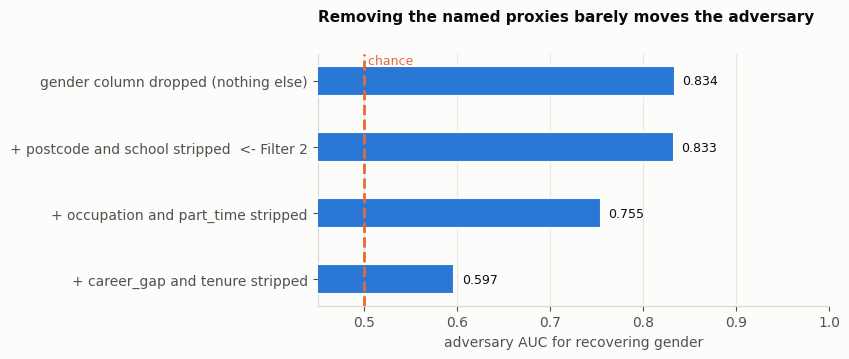

In [4]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

labels = [s[0] for s in steps]
scores = [adversary_auc(X.drop(columns=d)) for _, d in steps]

fig, ax = plt.subplots(figsize=(8.6, 3.7))
bars = ax.barh(labels, scores, color=BLUE, height=0.46, zorder=3, edgecolor=SURFACE, lw=1.5)
ax.axvline(0.5, color=ORANGE, lw=2, ls='--', zorder=4)
ax.text(0.5, 1.0, ' chance', color=ORANGE, fontsize=9, va='top', ha='left',
        transform=ax.get_xaxis_transform())
for bar, s in zip(bars, scores):
    ax.text(s + 0.008, bar.get_y() + bar.get_height() / 2, f'{s:.3f}',
            va='center', fontsize=9, color=INK)
ax.set_xlim(0.45, 1.0)
ax.invert_yaxis()
tidy(ax)
ax.set_xlabel('adversary AUC for recovering gender')
ax.set_title('Removing the named proxies barely moves the adversary', loc='left', pad=24)
fig.tight_layout()
plt.savefig('../figures/01_proxy_decay.png', dpi=150, bbox_inches='tight')
plt.show()